In [1]:
# ============================================================
# PIPELINE B - PLAYER COUNTING  |  Cell 1: setup + load labels
# ============================================================
import os
for _v in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"]:
    os.environ[_v] = "4"

import numpy as np
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

DATA_DIR  = Path("../data")
IMAGE_DIR = DATA_DIR / "images"
MASTER    = DATA_DIR / "master.csv"

master = pd.read_csv(MASTER)
print("master.csv shape:", master.shape)
print("columns:", list(master.columns))

# Keep ONLY rows with a real count. Blank/NaN means 'not labelled', NOT zero.
labelled = master[master["num_players"].notna()].copy()
labelled["num_players"] = labelled["num_players"].astype(int)

print(f"\nLabelled-count images: {len(labelled)}  "
      f"({100*len(labelled)/len(master):.1f}% of dataset)")
print("\nPlayer-count distribution:")
print(labelled["num_players"].value_counts().sort_index())
print("\nStats:", labelled["num_players"].describe()[["mean","min","max"]].round(2).to_dict())

master.csv shape: (3659, 68)
columns: ['image', 'labelled_by', 'num_players', 'submitted_by', 'c01', 'c02', 'c03', 'c04', 'c05', 'c06', 'c07', 'c08', 'c09', 'c10', 'c11', 'c12', 'c13', 'c14', 'c15', 'c16', 'c17', 'c18', 'c19', 'c20', 'c21', 'c22', 'c23', 'c24', 'c25', 'c26', 'c27', 'c28', 'c29', 'c30', 'c31', 'c32', 'c33', 'c34', 'c35', 'c36', 'c37', 'c38', 'c39', 'c40', 'c41', 'c42', 'c43', 'c44', 'c45', 'c46', 'c47', 'c48', 'c49', 'c50', 'c51', 'c52', 'c53', 'c54', 'c55', 'c56', 'c57', 'c58', 'c59', 'c60', 'c61', 'c62', 'c63', 'c64']

Labelled-count images: 2263  (61.8% of dataset)

Player-count distribution:
num_players
0     157
1     988
2     647
3     172
4      98
5      63
6      39
7      33
8      31
9      15
10      8
11      4
12      3
20      3
21      2
Name: count, dtype: int64

Stats: {'mean': 2.04, 'min': 0.0, 'max': 21.0}


In [2]:
print(labelled[labelled["num_players"] >= 12][["image","num_players"]].to_string(index=False))

                 image  num_players
KKRvsCSK_image_105.jpg           12
 SRHvsMI_image_199.jpg           21
 SRHvsMI_image_217.jpg           20
 SRHvsMI_image_235.jpg           12
 SRHvsMI_image_253.jpg           20
 SRHvsMI_image_285.jpg           20
  SRHvsMI_image_33.jpg           12
  SRHvsMI_image_87.jpg           21


In [3]:
# ============================================================
# PIPELINE B  |  Cell 2: whole-image feature extractor
# ============================================================
import cv2

# HSV grass range (same family you've used elsewhere). Non-grass = candidate players/objects.
LOWER_GREEN = np.array([35, 40, 40])
UPPER_GREEN = np.array([85, 255, 255])

def count_feats_for_image(path):
    """~15 image-level features that describe player content & fragmentation."""
    img = cv2.imread(str(path))
    if img is None:
        return None  # missing/corrupt file -> caller skips it
    img = cv2.resize(img, (800, 600))
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # --- non-grass (foreground) mask ---
    grass = cv2.inRange(hsv, LOWER_GREEN, UPPER_GREEN)
    nongrass = cv2.bitwise_not(grass)
    k_open  = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    k_close = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 9))  # tall = bridge vertical bodies
    m = cv2.morphologyEx(nongrass, cv2.MORPH_OPEN,  k_open)
    m = cv2.morphologyEx(m,        cv2.MORPH_CLOSE, k_close)

    total = img.shape[0] * img.shape[1]
    nongrass_frac = float(m.sum()) / 255.0 / total          # how much non-grass
    grass_frac    = float(grass.sum()) / 255.0 / total      # how much field

    # --- connected blobs in the foreground mask ---
    n_lab, lab, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    areas = stats[1:, cv2.CC_STAT_AREA] if n_lab > 1 else np.array([])
    # player-plausible blobs: not noise, not huge stands
    plausible = areas[(areas >= 150) & (areas <= 8000)]
    n_blobs_all       = int(len(areas))
    n_blobs_plausible = int(len(plausible))

    def s(a, f, d=0.0):
        return float(f(a)) if len(a) else d
    blob_mean = s(plausible, np.mean)
    blob_std  = s(plausible, np.std)
    blob_max  = s(plausible, np.max)
    blob_med  = s(plausible, np.median)
    blob_sum_frac = float(plausible.sum()) / total if len(plausible) else 0.0

    # --- edges (player regions are edge-rich vs smooth grass) ---
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 80, 160)
    edge_density = float(edges.sum()) / 255.0 / total

    # --- colour variety in foreground (distinct jersey colours ~ distinct players) ---
    sat = hsv[:, :, 1]; val = hsv[:, :, 2]
    fg = m > 0
    sat_fg_mean = float(sat[fg].mean()) if fg.any() else 0.0
    val_fg_std  = float(val[fg].std())  if fg.any() else 0.0
    hue_fg = hsv[:, :, 0][fg]
    hue_hist = np.histogram(hue_fg, bins=12, range=(0, 180))[0] if fg.any() else np.zeros(12)
    hue_hist = hue_hist / (hue_hist.sum() + 1e-9)
    distinct_hues = int((hue_hist > 0.03).sum())  # how many hue bins are meaningfully present

    return np.array([
        nongrass_frac, grass_frac,
        n_blobs_all, n_blobs_plausible,
        blob_mean, blob_std, blob_max, blob_med, blob_sum_frac,
        edge_density, sat_fg_mean, val_fg_std, distinct_hues,
    ], dtype=np.float32)

FEAT_NAMES = ["nongrass_frac","grass_frac","n_blobs_all","n_blobs_plausible",
              "blob_mean","blob_std","blob_max","blob_med","blob_sum_frac",
              "edge_density","sat_fg_mean","val_fg_std","distinct_hues"]

# quick test on ONE image before running the whole set
_test = labelled.iloc[0]
_f = count_feats_for_image(IMAGE_DIR / _test["image"])
if _f is None:
    print("⚠️ Could not read:", IMAGE_DIR / _test["image"], "- check IMAGE_DIR / filename pattern")
else:
    print("OK - feature vector length:", len(_f))
    for n, v in zip(FEAT_NAMES, _f):
        print(f"  {n:18s} {v:.4f}")

OK - feature vector length: 13
  nongrass_frac      0.9815
  grass_frac         0.0238
  n_blobs_all        1.0000
  n_blobs_plausible  0.0000
  blob_mean          0.0000
  blob_std           0.0000
  blob_max           0.0000
  blob_med           0.0000
  blob_sum_frac      0.0000
  edge_density       0.0442
  sat_fg_mean        146.7163
  val_fg_std         63.9943
  distinct_hues      4.0000


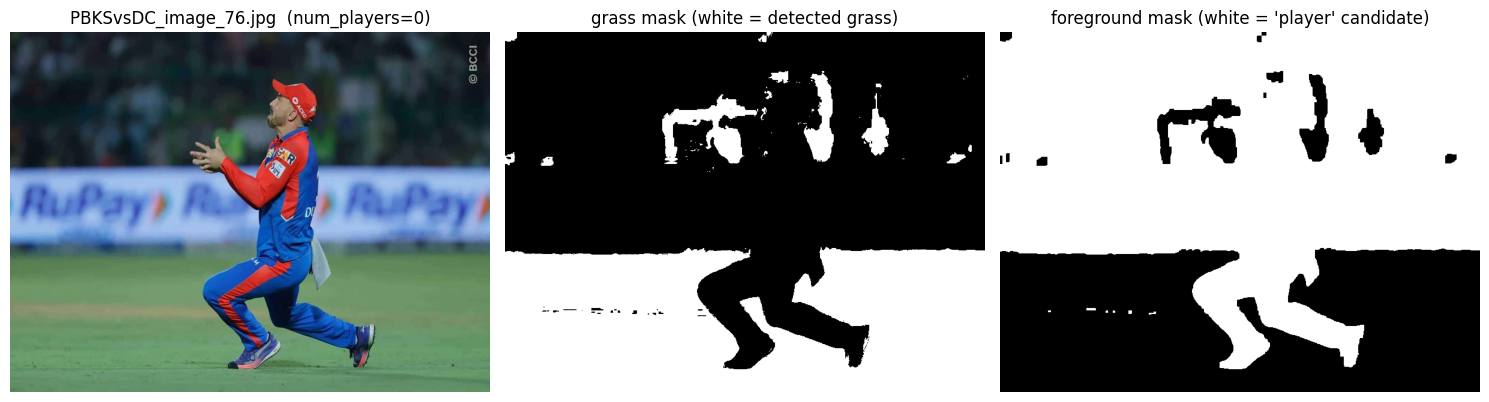


feature            value
  nongrass_frac      0.6396
  grass_frac         0.3622
  n_blobs_all        7.0000
  n_blobs_plausible  0.0000
  blob_mean          0.0000
  blob_std           0.0000
  blob_max           0.0000
  blob_med           0.0000
  blob_sum_frac      0.0000
  edge_density       0.0213
  sat_fg_mean        123.0201
  val_fg_std         76.5792
  distinct_hues      3.0000


In [7]:
# Diagnostic: show ONE random image + its mask + its feature table
import matplotlib.pyplot as plt
import numpy as np

r = labelled.sample(1, random_state=None).iloc[0]   # random each run
p = IMAGE_DIR / r["image"]

img = cv2.imread(str(p))
img = cv2.resize(img, (800, 600))
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
grass = cv2.inRange(hsv, LOWER_GREEN, UPPER_GREEN)
nongrass = cv2.bitwise_not(grass)
k_open  = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
k_close = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 9))
m = cv2.morphologyEx(nongrass, cv2.MORPH_OPEN,  k_open)
m = cv2.morphologyEx(m,        cv2.MORPH_CLOSE, k_close)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax[0].set_title(f"{r['image']}  (num_players={r['num_players']})")
ax[1].imshow(grass, cmap="gray"); ax[1].set_title("grass mask (white = detected grass)")
ax[2].imshow(m, cmap="gray");     ax[2].set_title("foreground mask (white = 'player' candidate)")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

f = count_feats_for_image(p)
print(f"\n{'feature':18s} value")
for n, v in zip(FEAT_NAMES, f):
    print(f"  {n:18s} {v:.4f}")

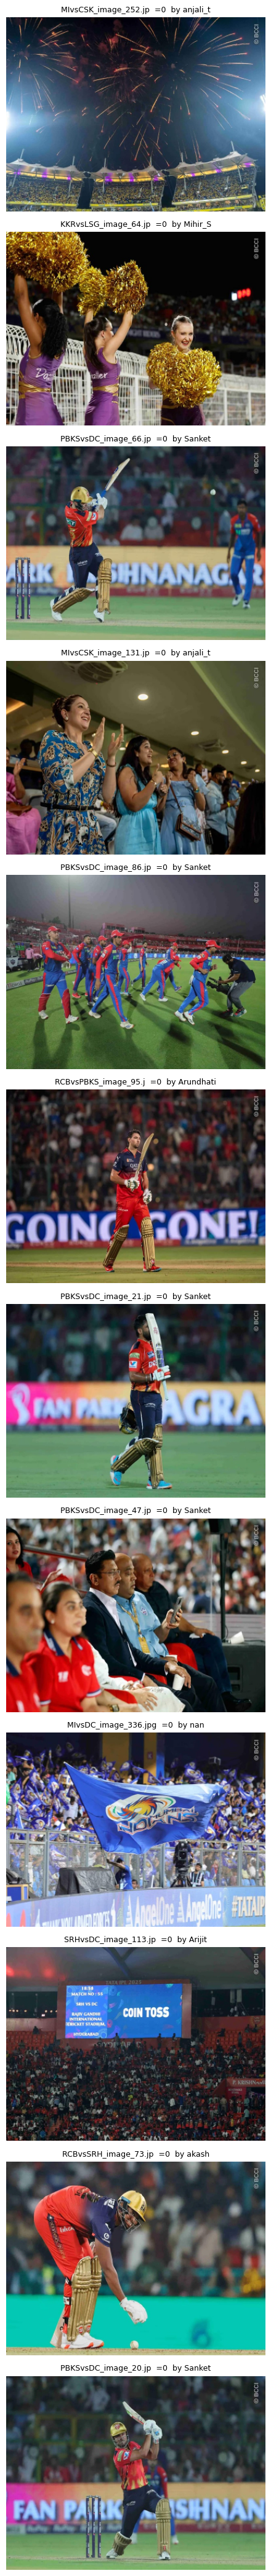

In [13]:
import matplotlib.pyplot as plt
zeros = labelled[labelled["num_players"] == 0].sample(12, random_state=2)
fig, axes = plt.subplots(12, 1, figsize=(42, 42))
for ax, (_, r) in zip(axes.ravel(), zeros.iterrows()):
    im = cv2.imread(str(IMAGE_DIR / r["image"]))
    ax.imshow(cv2.cvtColor(cv2.resize(im,(400,300)), cv2.COLOR_BGR2RGB))
    ax.set_title(f"{r['image'][:20]}  =0  by {r.get('labelled_by','?')}", fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

In [14]:
# ============================================================
# PIPELINE B - PLAYER COUNTING  |  Cell 1 (revised): load + drop unreliable zeros
# ============================================================
import os
for _v in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"]:
    os.environ[_v] = "4"

import numpy as np
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

DATA_DIR  = Path("../data")
IMAGE_DIR = DATA_DIR / "images"
MASTER    = DATA_DIR / "master.csv"

master = pd.read_csv(MASTER)
print("master.csv shape:", master.shape)

# Keep rows with a real count (blank = unlabelled, skip), then DROP zeros (unreliable labels).
labelled = master[master["num_players"].notna()].copy()
labelled["num_players"] = labelled["num_players"].astype(int)

n_before = len(labelled)
n_zeros  = int((labelled["num_players"] == 0).sum())
labelled = labelled[labelled["num_players"] > 0].copy()   # <-- drop all 0-counts

print(f"\nLabelled rows: {n_before}  |  dropped zeros: {n_zeros}  |  remaining: {len(labelled)}")
print("\nPlayer-count distribution (zeros removed):")
print(labelled["num_players"].value_counts().sort_index())
print("\nStats:", labelled["num_players"].describe()[["mean","min","max"]].round(2).to_dict())

# image-name column is 'image' in this dataset
IMG_COL = "image"

master.csv shape: (3659, 68)

Labelled rows: 2263  |  dropped zeros: 157  |  remaining: 2106

Player-count distribution (zeros removed):
num_players
1     988
2     647
3     172
4      98
5      63
6      39
7      33
8      31
9      15
10      8
11      4
12      3
20      3
21      2
Name: count, dtype: int64

Stats: {'mean': 2.19, 'min': 1.0, 'max': 21.0}


In [15]:
# ============================================================
# PIPELINE B  |  Cell 2 (revised): robust whole-image features
# (no grass/blob assumptions - those failed on tight crops + crowds)
# ============================================================
import cv2

def count_feats_for_image(path):
    """Whole-image hand-crafted features that survive crowd backgrounds & tight crops.
       Describes visual busyness, colour spread, and vertical structure - which
       loosely scale with how many players occupy the frame."""
    img = cv2.imread(str(path))
    if img is None:
        return None
    img = cv2.resize(img, (800, 600))
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    H, W = gray.shape
    total = H * W

    # --- edges: player regions (jersey seams, limbs, logos) are edge-rich ---
    edges = cv2.Canny(gray, 80, 160)
    edge_density = float(edges.sum()) / 255.0 / total

    # gradient magnitude stats (busyness without thresholding)
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    mag = np.sqrt(gx*gx + gy*gy)
    grad_mean = float(mag.mean())
    grad_std  = float(mag.std())

    # --- colour spread: more players -> more distinct jersey colours/saturation ---
    hue, sat, val = hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]
    sat_mean, sat_std = float(sat.mean()), float(sat.std())
    val_mean, val_std = float(val.mean()), float(val.std())

    # saturated (vivid) pixels are usually jerseys, not crowd/field
    vivid = (sat > 90) & (val > 60)
    vivid_frac = float(vivid.mean())

    # hue spread among vivid pixels: how many distinct strong colours present
    hue_v = hue[vivid]
    if hue_v.size:
        hh = np.histogram(hue_v, bins=18, range=(0,180))[0].astype(float)
        hh /= hh.sum() + 1e-9
        distinct_hues = int((hh > 0.03).sum())
        hue_entropy = float(-(hh[hh>0] * np.log(hh[hh>0])).sum())
    else:
        distinct_hues, hue_entropy = 0, 0.0

    # --- vertical structure: standing players create vertical edge columns ---
    col_edge = edges.sum(axis=0).astype(float) / 255.0      # edge count per column
    col_active = int((col_edge > (0.10 * H)).sum())          # columns with strong vertical content
    col_active_frac = col_active / W

    # --- coarse spatial spread: split into 4x4 tiles, how many are 'busy' ---
    tiles_busy = 0
    th, tw = H//4, W//4
    for r in range(4):
        for cc in range(4):
            t = edges[r*th:(r+1)*th, cc*tw:(cc+1)*tw]
            if (t.sum()/255.0) / (th*tw) > 0.04:
                tiles_busy += 1
    tiles_busy_frac = tiles_busy / 16.0

    return np.array([
        edge_density, grad_mean, grad_std,
        sat_mean, sat_std, val_mean, val_std,
        vivid_frac, distinct_hues, hue_entropy,
        col_active_frac, tiles_busy_frac,
    ], dtype=np.float32)

FEAT_NAMES = ["edge_density","grad_mean","grad_std",
              "sat_mean","sat_std","val_mean","val_std",
              "vivid_frac","distinct_hues","hue_entropy",
              "col_active_frac","tiles_busy_frac"]

# sanity test on 3 images of different counts
for cnt in [1, 2, 5]:
    sub = labelled[labelled["num_players"] == cnt]
    if len(sub) == 0: continue
    r = sub.iloc[0]
    f = count_feats_for_image(IMAGE_DIR / r[IMG_COL])
    if f is None:
        print(f"num_players={cnt}: UNREADABLE {r[IMG_COL]}"); continue
    print(f"\nnum_players={cnt}  ({r[IMG_COL]})")
    print("  " + "  ".join(f"{n}={v:.3f}" for n,v in zip(FEAT_NAMES, f)))


num_players=1  (GTvsLSG_image_0.jpg)
  edge_density=0.044  grad_mean=41.129  grad_std=70.974  sat_mean=145.774  sat_std=65.887  val_mean=120.575  val_std=64.051  vivid_frac=0.518  distinct_hues=4.000  hue_entropy=1.490  col_active_frac=0.125  tiles_busy_frac=0.375

num_players=2  (GTvsLSG_image_10.jpg)
  edge_density=0.074  grad_mean=53.069  grad_std=65.968  sat_mean=116.142  sat_std=69.021  val_mean=120.790  val_std=57.878  vivid_frac=0.388  distinct_hues=4.000  hue_entropy=1.453  col_active_frac=0.135  tiles_busy_frac=0.750

num_players=5  (GTvsLSG_image_17.jpg)
  edge_density=0.061  grad_mean=43.639  grad_std=88.267  sat_mean=127.796  sat_std=51.185  val_mean=89.622  val_std=62.254  vivid_frac=0.412  distinct_hues=6.000  hue_entropy=1.469  col_active_frac=0.240  tiles_busy_frac=0.688


In [16]:
# ============================================================
# PIPELINE B  |  Cell 3: extract features for all labelled images
# ============================================================
from tqdm.auto import tqdm

X_list, y_list, kept_names = [], [], []
missing = 0

for _, r in tqdm(labelled.iterrows(), total=len(labelled), desc="Extracting count features"):
    f = count_feats_for_image(IMAGE_DIR / r[IMG_COL])
    if f is None:
        missing += 1
        continue
    X_list.append(f)
    y_list.append(int(r["num_players"]))
    kept_names.append(r[IMG_COL])

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=int)

# clean any stray non-finite values
bad = (~np.isfinite(X)).sum()
if bad:
    print(f"Cleaning {bad} non-finite values")
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

print(f"\nExtracted: {X.shape[0]} images x {X.shape[1]} features")
print(f"Unreadable/skipped: {missing}")
print(f"Count range: {y.min()}-{y.max()}, mean {y.mean():.2f}")

Extracting count features:   0%|          | 0/2106 [00:00<?, ?it/s]

[ WARN:0@27802.778] global loadsave.cpp:278 findDecoder imread_('../data/images/SRHvsMI_image_261.jpg'): can't open/read file: check file path/integrity
[ WARN:0@27802.778] global loadsave.cpp:278 findDecoder imread_('../data/images/SRHvsMI_image_262.jpg'): can't open/read file: check file path/integrity
[ WARN:0@27802.779] global loadsave.cpp:278 findDecoder imread_('../data/images/SRHvsMI_image_263.jpg'): can't open/read file: check file path/integrity
[ WARN:0@27802.779] global loadsave.cpp:278 findDecoder imread_('../data/images/SRHvsMI_image_264.jpg'): can't open/read file: check file path/integrity
[ WARN:0@27802.782] global loadsave.cpp:278 findDecoder imread_('../data/images/SRHvsMI_image_265.jpg'): can't open/read file: check file path/integrity
[ WARN:0@27802.782] global loadsave.cpp:278 findDecoder imread_('../data/images/SRHvsMI_image_266.jpg'): can't open/read file: check file path/integrity
[ WARN:0@27802.782] global loadsave.cpp:278 findDecoder imread_('../data/images/SR


Extracted: 2056 images x 12 features
Unreadable/skipped: 50
Count range: 1-21, mean 2.16


In [17]:
# ============================================================
# PIPELINE B  |  Cell 4: grid-derived count baseline (from master.csv labels)
# ============================================================
GRID = 8
cell_cols = [f"c{i:02d}" for i in range(1, 65)]

def count_players_from_grid(label_row):
    """Connected same-team regions (4-connectivity) on the 8x8 grid = player estimate."""
    g = np.array(label_row, dtype=float).reshape(GRID, GRID)
    g = np.nan_to_num(g, nan=0.0).astype(int)
    seen = np.zeros_like(g, dtype=bool)
    n = 0
    for rr in range(GRID):
        for cc in range(GRID):
            t = g[rr, cc]
            if t == 0 or seen[rr, cc]:
                continue
            n += 1
            stack = [(rr, cc)]; seen[rr, cc] = True
            while stack:
                yy, xx = stack.pop()
                for dy, dx in ((1,0),(-1,0),(0,1),(0,-1)):
                    ny, nx = yy+dy, xx+dx
                    if 0 <= ny < GRID and 0 <= nx < GRID and not seen[ny, nx] and g[ny, nx] == t:
                        seen[ny, nx] = True; stack.append((ny, nx))
    return n

# build a lookup from image name -> its 64 grid labels
grid_lookup = master.set_index("image")[cell_cols]

grid_counts = []
for name in kept_names:                      # same images/order as X, y
    row = grid_lookup.loc[name].to_numpy()
    grid_counts.append(count_players_from_grid(row))
grid_counts = np.array(grid_counts, dtype=int)

# evaluate the grid baseline against the (cleaned) num_players labels
def count_scores(pred, true, tag):
    pred = np.asarray(pred); true = np.asarray(true)
    mae  = np.mean(np.abs(pred - true))
    rmse = np.sqrt(np.mean((pred - true)**2))
    exact = np.mean(pred == true)
    w1   = np.mean(np.abs(pred - true) <= 1)
    print(f"{tag:28s} MAE={mae:.3f}  RMSE={rmse:.3f}  exact={exact:.1%}  within\u00b11={w1:.1%}")
    return mae, rmse, exact, w1

print("BASELINE - count from ground-truth grid (no training):")
_ = count_scores(grid_counts, y, "Grid connected-components")

# how do the two even relate?
print(f"\nGrid count range: {grid_counts.min()}-{grid_counts.max()}, mean {grid_counts.mean():.2f}")
print(f"Label count range: {y.min()}-{y.max()}, mean {y.mean():.2f}")

BASELINE - count from ground-truth grid (no training):
Grid connected-components    MAE=0.786  RMSE=1.895  exact=66.0%  within±1=85.4%

Grid count range: 0-5, mean 1.55
Label count range: 1-21, mean 2.16


In [18]:
# ============================================================
# PIPELINE B  |  Cell 5: train count regressors, CV, compare to grid baseline
# ============================================================
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

CAP = 12  # clip TRAINING targets at this to limit rare-outlier distortion (eval still on true y)
y_train_target = np.clip(y, None, CAP)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Ridge": Pipeline([("sc", StandardScaler()), ("m", Ridge(alpha=1.0))]),
    "RandomForest": RandomForestRegressor(n_estimators=300, max_depth=12,
                        min_samples_leaf=3, n_jobs=4, random_state=42),
    "HistGB": HistGradientBoostingRegressor(max_iter=300, learning_rate=0.08,
                        max_depth=6, random_state=42),
}

def rounded_scores(pred_real, true, tag):
    pred = np.clip(np.rint(pred_real), 1, None).astype(int)  # counts are >=1 here
    return count_scores(pred, true, tag)

print("5-fold CV (predictions rounded to integers):\n")
results = {}
for name, mdl in models.items():
    pred = cross_val_predict(mdl, X, y_train_target, cv=cv, n_jobs=1)
    results[name] = np.clip(np.rint(pred), 1, None).astype(int)
    rounded_scores(pred, y, name)

print("\nGrid baseline (for reference):")
count_scores(grid_counts, y, "Grid connected-components")

# breakdown by count range: where does each method win?
print("\n--- within\u00b11 by count range ---")
for lo, hi, lbl in [(1,3,"1-3 (common)"), (4,7,"4-7"), (8,99,"8+ (rare)")]:
    msk = (y >= lo) & (y <= hi)
    if msk.sum() == 0: continue
    line = f"{lbl:14s} n={int(msk.sum()):4d} | grid={np.mean(np.abs(grid_counts[msk]-y[msk])<=1):.0%}"
    for name in models:
        line += f"  {name}={np.mean(np.abs(results[name][msk]-y[msk])<=1):.0%}"
    print(line)

5-fold CV (predictions rounded to integers):

Ridge                        MAE=0.929  RMSE=1.638  exact=44.4%  within±1=81.1%
RandomForest                 MAE=0.768  RMSE=1.454  exact=52.3%  within±1=84.9%
HistGB                       MAE=0.756  RMSE=1.458  exact=53.6%  within±1=85.4%

Grid baseline (for reference):
Grid connected-components    MAE=0.786  RMSE=1.895  exact=66.0%  within±1=85.4%

--- within±1 by count range ---
1-3 (common)   n=1771 | grid=96%  Ridge=89%  RandomForest=91%  HistGB=92%
4-7            n= 226 | grid=22%  Ridge=42%  RandomForest=55%  HistGB=57%
8+ (rare)      n=  59 | grid=0%  Ridge=0%  RandomForest=3%  HistGB=10%


In [ ]:
# ============================================================
# PIPELINE B  |  Cell 6 (self-contained): hybrid counter + save model
# ============================================================
import joblib
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.ensemble import HistGradientBoostingRegressor

CAP = 12
SWITCH = 3
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# recompute HistGB out-of-fold predictions (independent of Cell 5)
_histgb = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.08,
                                        max_depth=6, random_state=42)
_oof_real = cross_val_predict(_histgb, X, np.clip(y, None, CAP), cv=cv, n_jobs=1)
histgb_oof = np.clip(np.rint(_oof_real), 1, None).astype(int)

hybrid = np.where(grid_counts <= SWITCH, grid_counts, histgb_oof).astype(int)
hybrid = np.clip(hybrid, 1, None)

def count_scores(pred, true, tag):
    pred = np.asarray(pred); true = np.asarray(true)
    mae=np.mean(np.abs(pred-true)); rmse=np.sqrt(np.mean((pred-true)**2))
    print(f"{tag:30s} MAE={mae:.3f}  RMSE={rmse:.3f}  exact={np.mean(pred==true):.1%}  within\u00b11={np.mean(np.abs(pred-true)<=1):.1%}")

print("=== FINAL COMPARISON (5-fold CV, out-of-fold) ===\n")
count_scores(grid_counts, y, "Grid only")
count_scores(histgb_oof, y, "HistGB only")
count_scores(hybrid,     y, "HYBRID (grid<=3 else HistGB)")

print("\n--- within\u00b11 by count range ---")
rows_for_table = []
for lo, hi, lbl in [(1,3,"1-3 (common)"),(4,7,"4-7"),(8,99,"8+ (rare)"),(1,99,"ALL")]:
    msk=(y>=lo)&(y<=hi)
    if msk.sum()==0: continue
    g=np.mean(np.abs(grid_counts[msk]-y[msk])<=1)
    h=np.mean(np.abs(histgb_oof[msk]-y[msk])<=1)
    hy=np.mean(np.abs(hybrid[msk]-y[msk])<=1)
    print(f"{lbl:14s} n={int(msk.sum()):4d} | grid={g:.0%}  histgb={h:.0%}  hybrid={hy:.0%}")
    rows_for_table.append({"range":lbl,"n":int(msk.sum()),
        "grid_w1":round(g,3),"histgb_w1":round(h,3),"hybrid_w1":round(hy,3)})

final_histgb = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.08,
                    max_depth=6, random_state=42).fit(X, np.clip(y, None, CAP))
joblib.dump({"model":final_histgb,"feat_names":FEAT_NAMES,"switch":SWITCH,"cap":CAP},
            "count_model_hybrid.pkl")
print("\nSaved count_model_hybrid.pkl")

NameError: name 'histgb_oof' is not defined

In [21]:
for v in ["results", "grid_counts", "X", "y", "kept_names"]:
    print(v, "OK" if v in dir() else "MISSING")

results OK
grid_counts OK
X OK
y OK
kept_names OK
